#Decision Trees

**Objective: Learn how to apply the decision trees.**

Decision trees are widely used in the banking industry due to their high accuracy and ability to formulate a model in plain language. Since government organizations in many countries carefully monitor lending practices, banks must be able to explain why one applicant was rejected for a loan while the others were approved.

In this lab, we will develop a simple credit approval model using decision trees.

**Source: Lantz Brett, Machine Learning with R. Packt Publishing**

# I. Collecting data

The idea behind our credit model is to identify factors that are predictive of higher risk of default.

We will use a Data available in a dataset donated to the UCI Machine Learning Data Repository by Hans Hofmann of the University of Hamburg.

The dataset contains information on loans obtained from a credit agency in Germany.

The credit dataset includes 1,000 examples on loans, plus a set of numeric and nominal features indicating the characteristics of the loan and the loan applicant.

A class variable indicates whether the loan went into default.


# II. Exploring and preparing the data

## A. Exploring the data

Let’s import the data. The data is available on Canvas, named **credit.csv**.

**1. Import and read the csv data file.**

**2. Examine the structure of the data frame.**

**3.  Which features can be a possible predictor of a default loan?**

**4. How can you check and study those features? Explain.**

**5.  What percentage of the loans in the dataset went into default? is it high? How this result can aﬀect the loaning bank?**

## B. Data preparation

**6.Convert categorical data into numerical.**

**7. Check if your dataset is randomized.**

# III. Training a model on the data

**8. Split the data into training and testing sets.**

**9. Apply the decision tree algorithm.**

**10. Visualize the model after training**

**11. Find the best predictor features.**

# IV. Evaluating model performance

**12. Check the accuracy of the model. Check other metrics.**

**13. Is this model a good model?**

# V. Improving model performance

**14. How can you improve the performance of your decision tree model?**

**15. Apply different ways of improve the model. Discuss and explain your results.**

In [7]:
# Import and read the csv data file
import pandas as pd
credit = pd.read_csv("credit-2.csv")
credit.head()

,checking_balance,months_loan_duration,credit_history,purpose,amount,savings_balance,employment_duration,percent_of_income,years_at_residence,age,other_credit,housing,existing_loans_count,job,dependents,phone,default
0,< 0 DM,6,critical,furniture/appliances,1169,unknown,> 7 years,4,4,67,none,own,2,skilled,1,yes,no
1,1 - 200 DM,48,good,furniture/appliances,5951,< 100 DM,1 - 4 years,2,2,22,none,own,1,skilled,1,no,yes
2,unknown,12,critical,education,2096,< 100 DM,4 - 7 years,2,3,49,none,own,1,unskilled,2,no,no
3,< 0 DM,42,good,furniture/appliances,7882,< 100 DM,4 - 7 years,2,4,45,none,other,1,skilled,2,no,no
4,< 0 DM,24,poor,car,4870,< 100 DM,1 - 4 years,3,4,53,none,other,2,skilled,2,no,yes


In [8]:
# Examine the structure of the data frame.
credit.info()
credit.describe()
credit.describe(include='object')
credit.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   checking_balance      1000 non-null   object
 1   months_loan_duration  1000 non-null   int64 
 2   credit_history        1000 non-null   object
 3   purpose               1000 non-null   object
 4   amount                1000 non-null   int64 
 5   savings_balance       1000 non-null   object
 6   employment_duration   1000 non-null   object
 7   percent_of_income     1000 non-null   int64 
 8   years_at_residence    1000 non-null   int64 
 9   age                   1000 non-null   int64 
 10  other_credit          1000 non-null   object
 11  housing               1000 non-null   object
 12  existing_loans_count  1000 non-null   int64 
 13  job                   1000 non-null   object
 14  dependents            1000 non-null   int64 
 15  phone                 1000 non-null   o

(1000, 17)

# Which features can be a possible predictor of a default loan?

Checking balance, credit history, savings balance, employment duration, other credit, housing, and job could all be predictors of loan defaults. Higher balance, more skilled jobs, more credit history, more employment duration, and more savings balance could predict less likelihood of a default.

# How can you check and study those features? Explain.

You can look at a correlation matrix or use plots of those features.

In [9]:
import pandas as pd

# Convert categorical data into numerical using one-hot encoding
# This step is also present in cell TvEewW4-p_RX, but included here for self-containment of the fix.
credit_encoded = pd.get_dummies(credit, drop_first=True)

# Calculate correlation on the encoded DataFrame
credit_encoded.corr()

,months_loan_duration,amount,percent_of_income,years_at_residence,age,existing_loans_count,dependents,checking_balance_< 0 DM,checking_balance_> 200 DM,checking_balance_unknown,...,employment_duration_unemployed,other_credit_none,other_credit_store,housing_own,housing_rent,job_skilled,job_unemployed,job_unskilled,phone_yes,default_yes
months_loan_duration,1.000000,0.624984,0.074749,0.034067,-0.036136,-0.011284,-0.023834,0.022244,-0.076455,-0.063467,...,-0.005156,-0.067602,0.065688,-0.075169,-0.064417,0.055010,-0.044043,-0.181203,0.164718,0.214927
amount,0.624984,1.000000,-0.271316,0.028926,0.032716,0.020795,0.017142,-0.020912,-0.100510,-0.039485,...,0.086159,-0.048292,0.024262,-0.117497,-0.024611,-0.092636,-0.027969,-0.161757,0.276995,0.154739
percent_of_income,0.074749,-0.271316,1.000000,0.049302,0.058266,0.021669,-0.071207,0.046917,-0.041591,0.024961,...,-0.049420,-0.016139,0.056071,0.049922,-0.091373,0.042623,-0.087834,-0.057237,0.014413,0.072404
years_at_residence,0.034067,0.028926,0.049302,1.000000,0.266419,0.089625,0.042643,0.088350,-0.064303,0.001985,...,0.036123,0.016704,-0.054460,-0.297547,0.167285,-0.000657,-0.034545,0.009065,0.095359,0.002967
age,-0.036136,0.032716,0.058266,0.266419,1.000000,0.149254,0.118201,-0.011162,0.037504,0.062436,...,0.110562,-0.035362,-0.011080,0.006553,-0.212620,-0.148283,0.059954,0.043712,0.145259,-0.091127
existing_loans_count,-0.011284,0.020795,0.021669,0.089625,0.149254,1.000000,0.109667,-0.029195,-0.040213,0.094435,...,0.012684,-0.050290,0.023496,0.041386,-0.058070,-0.001471,0.059582,-0.010392,0.065553,-0.045732
dependents,-0.023834,0.017142,-0.071207,0.042643,0.118201,0.109667,1.000000,0.059041,-0.008700,0.010914,...,-0.041363,-0.072220,0.009335,-0.027579,-0.063033,-0.106737,-0.007723,0.145066,-0.014753,-0.003015
checking_balance_< 0 DM,0.022244,-0.020912,0.046917,0.088350,-0.011162,-0.029195,0.059041,1.000000,-0.159297,-0.495358,...,0.037301,-0.017494,0.011886,-0.125705,0.093310,-0.002879,-0.000428,0.023542,-0.067149,0.258333
checking_balance_> 200 DM,-0.076455,-0.100510,-0.041591,-0.064303,0.037504,-0.040213,-0.008700,-0.159297,1.000000,-0.209080,...,-0.049597,-0.002983,0.020206,0.018934,-0.035183,-0.022932,0.073347,0.014405,-0.028955,-0.044009
checking_balance_unknown,-0.063467,-0.039485,0.024961,0.001985,0.062436,0.094435,0.010914,-0.495358,-0.209080,1.000000,...,-0.063036,0.048829,-0.005009,0.104407,-0.066870,0.075366,-0.079080,-0.045023,0.061825,-0.322436


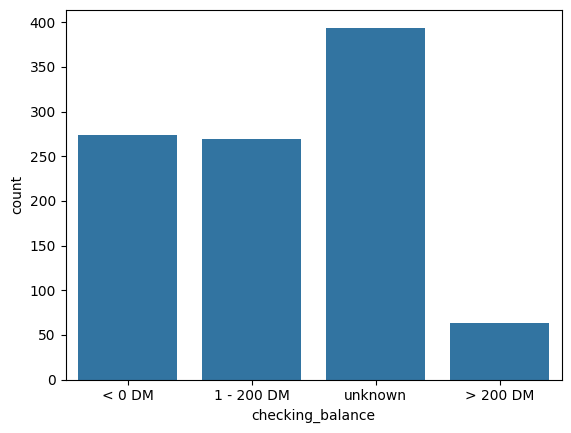

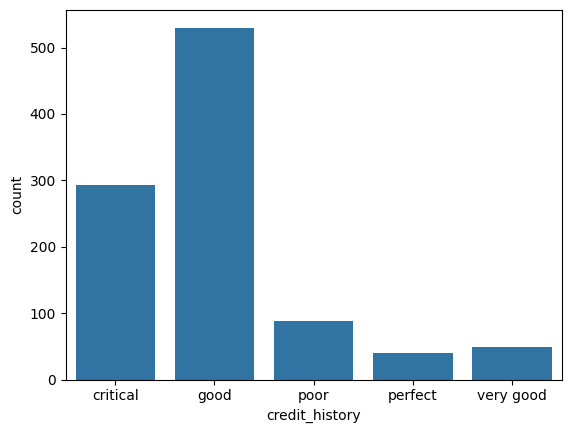

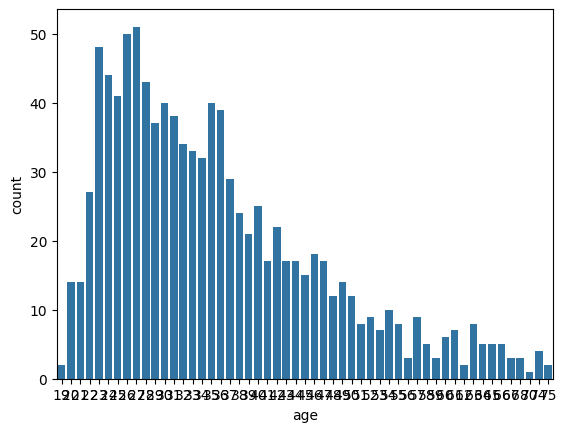

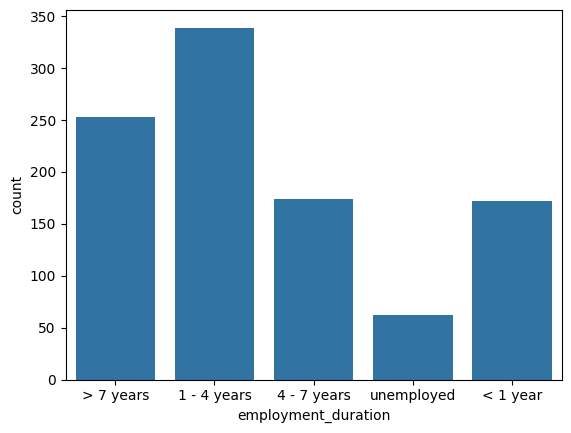

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="checking_balance", data=credit)
plt.show()

sns.countplot(x="credit_history", data=credit)
plt.show()

sns.countplot(x="age", data=credit)
plt.show()

sns.countplot(x="employment_duration", data=credit)
plt.show()

In [11]:
# What percentage of the loans in the dataset went into default? is it high? How this result can aﬀect the loaning bank?
credit["default"].value_counts(normalize=True) * 100

,proportion
default,
no,70.0
yes,30.0


In [12]:
# Convert categorical data into numerical.
credit_encoded = pd.get_dummies(credit, drop_first=True)

In [13]:
# Check if your dataset is randomized.
credit.head(20)
credit_encoded = credit_encoded.sample(frac=1, random_state=42).reset_index(drop=True)

In [14]:
# Split the data into training and testing sets.
from sklearn.model_selection import train_test_split

X = credit_encoded.drop("default_yes", axis=1)
y = credit_encoded["default_yes"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

In [15]:
# Apply the decision tree algorithm
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

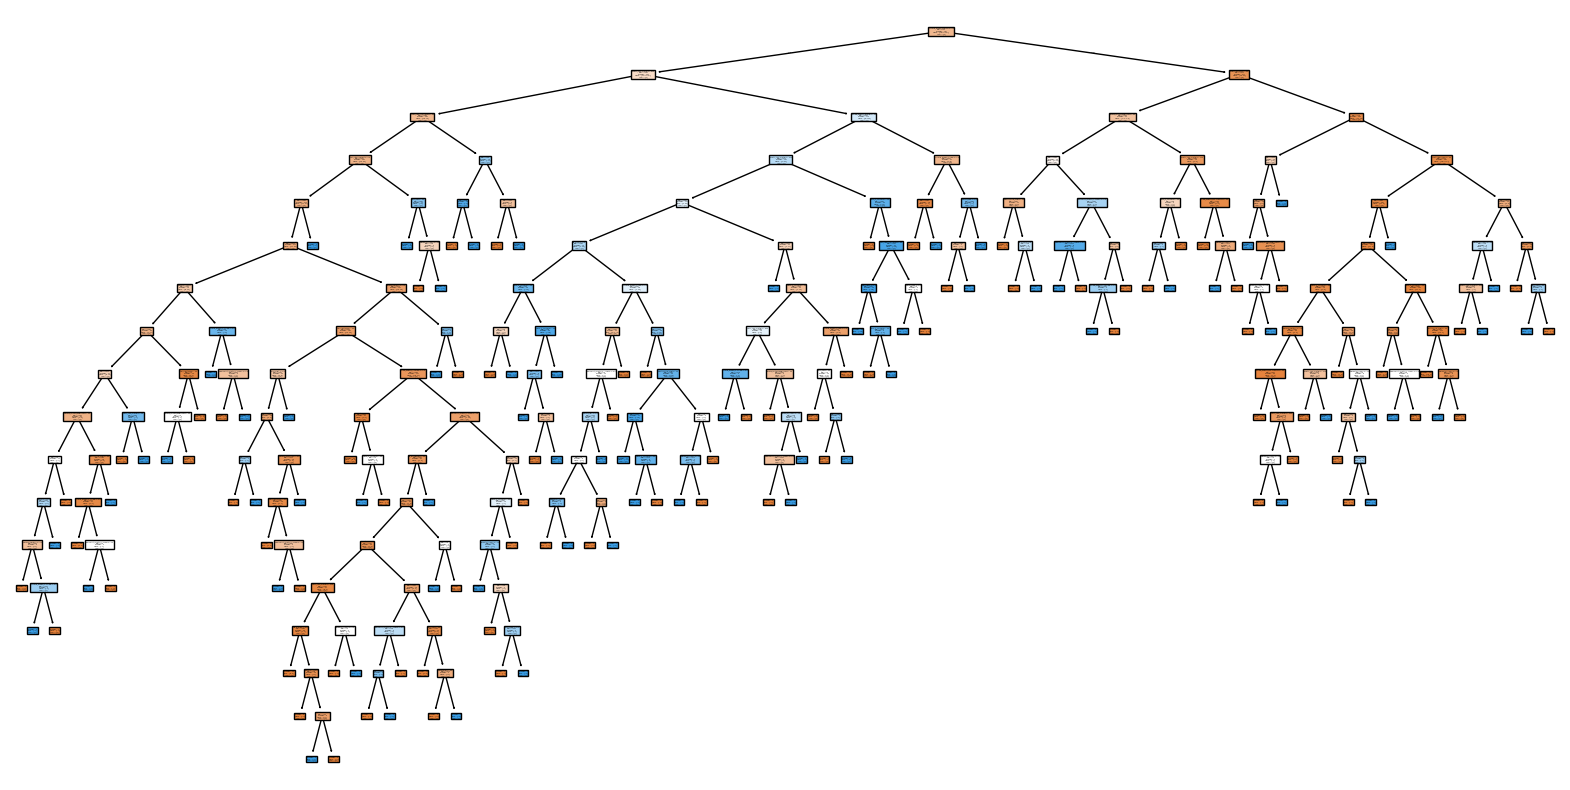

In [16]:
# Visualize the model after training
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(dt, feature_names=X.columns, class_names=True, filled=True)
plt.show()


In [17]:
# Find the best predictor features
import pandas as pd

feature_importance = pd.Series(dt.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False).head(10)


,0
age,0.184834
amount,0.146210
checking_balance_unknown,0.097977
months_loan_duration,0.095726
years_at_residence,0.061573
percent_of_income,0.052438
checking_balance_< 0 DM,0.045294
purpose_furniture/appliances,0.027210
other_credit_none,0.025343
phone_yes,0.019718


In [18]:
# Check the accuracy of the model. Check other metrics.
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = dt.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.66
[[161  49]
 [ 53  37]]
              precision    recall  f1-score   support

       False       0.75      0.77      0.76       210
        True       0.43      0.41      0.42        90

    accuracy                           0.66       300
   macro avg       0.59      0.59      0.59       300
weighted avg       0.66      0.66      0.66       300



# Is this model a good model?

It's not terrible, but not great, you would want to be more accurate, but it is more useful than random guessing. The recall score is relatively low.

# How can you improve the performance of your decision tree model?

I will try to deal with class imbalance and try using gradient boost.

In [19]:
# Apply different ways of improve the model. Discuss and explain your results.
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Compute class weights
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced',
                               classes=classes,
                               y=y_train)

class_weights = dict(zip(classes, weights))

# Create sample weights
sample_weights = y_train.map(class_weights)

In [20]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(exclude=["object"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"
)


gb_model = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("classifier", GradientBoostingClassifier(random_state=42))
])

gb_model.fit(X_train, y_train,
             classifier__sample_weight=sample_weights)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  Index([], dtype='object'))])),
                ('classifier', GradientBoostingClassifier(random_state=42))])

In [21]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = gb_model.predict(X_test)
y_prob = gb_model.predict_proba(X_test)[:,1]

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.72
[[157  53]
 [ 31  59]]
              precision    recall  f1-score   support

       False       0.84      0.75      0.79       210
        True       0.53      0.66      0.58        90

    accuracy                           0.72       300
   macro avg       0.68      0.70      0.69       300
weighted avg       0.74      0.72      0.73       300



# Random Forest

In [31]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_pred_rf = rf.predict(X_test)

print(f"Accuracy of Random Forest Classifier: {accuracy_score(y_test, rf_pred_rf)}")

Accuracy of Random Forest Classifier: 0.7433333333333333


# Bagging Classifier

In [32]:
from sklearn.ensemble import BaggingClassifier

bagging_clf = BaggingClassifier(
    n_estimators=50,
    bootstrap=True,
    n_jobs=-1,
    random_state=22
)

bagging_clf.fit(X_train, y_train)

y_pred_bagging = bagging_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_bagging)

print(f"Accuracy of Bagging Classifier: {accuracy:.2f}")

Accuracy of Bagging Classifier: 0.71


# AdaBoost Classifier

In [33]:
from sklearn.ensemble import AdaBoostClassifier

abc = AdaBoostClassifier(n_estimators=50, learning_rate=1, random_state=0)

abc.fit(X_train, y_train)

y_pred_abc = abc.predict(X_test)

print(f"Accuracy of AdaBoost Classifier: {accuracy_score(y_test, y_pred_abc):.4f}")

Accuracy of AdaBoost Classifier: 0.7000


# Voting Classifier

### Soft Voting

In [34]:
from sklearn.ensemble import VotingClassifier

model1 = rf
model2 = bagging_clf
model3 = abc

voting_clf = VotingClassifier(
    estimators=[('rf', model1), ('bc', model2), ('abc', model3)],
    voting='soft'
)

voting_clf.fit(X_train, y_train)
y_pred_clf = voting_clf.predict(X_test)

print(f"Accuracy of Soft Voting Classifier: {accuracy_score(y_test, y_pred_clf):.4f}")

Accuracy of Soft Voting Classifier: 0.7300


### Hard Voting

In [35]:
voting_clf_hard = VotingClassifier(
    estimators=[('rf', model1), ('bc', model2), ('abc', model3)],
    voting='hard'
)

voting_clf_hard.fit(X_train, y_train)
y_pred_clf_hard = voting_clf_hard.predict(X_test)

print(f"Accuracy of Hard Voting Classifier: {accuracy_score(y_test, y_pred_clf_hard):.4f}")

Accuracy of Hard Voting Classifier: 0.7233


# GridSearchCV

In [29]:
from sklearn.model_selection import GridSearchCV
# 2. Define the model (rf, bagging_clf, abc, voting_clf, voting_clf_hard are already defined)

# 3. Define the grid of hyperparameters to search specifically for RandomForestClassifier
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# 4. Create the GridSearchCV object
# The 'cv' parameter specifies the number of cross-validation folds (e.g., 5)
grid_search = GridSearchCV(
    estimator=rf, # Using the RandomForestClassifier
    param_grid=param_grid_rf, # Using the param_grid specific to RandomForest
    cv=5,
    scoring='accuracy', # Metric to optimize (e.g., accuracy, precision, recall)
    n_jobs=-1 # Use all available processors
)

# 5. Fit the GridSearchCV object to the training data
# This step performs the exhaustive search and cross-validation
grid_search.fit(X_train, y_train)

# 6. View the results
print("Best parameters found:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

# 7. Evaluate the best model on the test data
best_model = grid_search.best_estimator_
test_score = best_model.score(X_test, y_test)
print("Test set accuracy with best model:", test_score)

Best parameters found: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best cross-validation score: 0.76
Test set accuracy with best model: 0.75


# Compare Model Performance

In [38]:
# Compare perforamance of all models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Print accuracy, precision, recall, and f1 for rf, bagging, adaboost, hard voting, and soft voting in a table
accuracy_rf = accuracy_score(y_test, rf_pred_rf)
precision_rf = precision_score(y_test, rf_pred_rf)
recall_rf = recall_score(y_test, rf_pred_rf)
f1_rf = f1_score(y_test, rf_pred_rf)

accuracy_bagging = accuracy_score(y_test, y_pred_bagging)
precision_bagging = precision_score(y_test, y_pred_bagging)
recall_bagging = recall_score(y_test, y_pred_bagging)
f1_bagging = f1_score(y_test, y_pred_bagging)

accuracy_ada = accuracy_score(y_test, y_pred_abc)
precision_ada = precision_score(y_test, y_pred_abc)
recall_ada = recall_score(y_test, y_pred_abc)
f1_ada = f1_score(y_test, y_pred_abc)

accuracy_hard = accuracy_score(y_test, y_pred_clf_hard)
precision_hard = precision_score(y_test, y_pred_clf_hard)
recall_hard = recall_score(y_test, y_pred_clf_hard)
f1_hard = f1_score(y_test, y_pred_clf_hard)

accuracy_soft = accuracy_score(y_test, y_pred_clf)
precision_soft = precision_score(y_test, y_pred_clf)
recall_soft = recall_score(y_test, y_pred_clf)
f1_soft = f1_score(y_test, y_pred_clf)

# Same for best model from GridSearchCV
accuracy_best = accuracy_score(y_test, best_model.predict(X_test))
precision_best = precision_score(y_test, best_model.predict(X_test))
recall_best = recall_score(y_test, best_model.predict(X_test))
f1_best = f1_score(y_test, best_model.predict(X_test))

# Print all model results in table
print("Model\t\tAccuracy\tPrecision\tRecall\t\tF1")
print(f"Random Forest\t{accuracy_rf:.4f}\t\t{precision_rf:.4f}\t\t{recall_rf:.4f}\t\t{f1_rf:.4f}")
print(f"Bagging\t\t{accuracy_bagging:.4f}\t\t{precision_bagging:.4f}\t\t{recall_bagging:.4f}\t\t{f1_bagging:.4f}")
print(f"AdaBoost\t\t{accuracy_ada:.4f}\t\t{precision_ada:.4f}\t\t{recall_ada:.4f}\t\t{f1_ada:.4f}")
print(f"Hard Voting\t{accuracy_hard:.4f}\t\t{precision_hard:.4f}\t\t{recall_hard:.4f}\t\t{f1_hard:.4f}")
print(f"Soft Voting\t{accuracy_soft:.4f}\t\t{precision_soft:.4f}\t\t{recall_soft:.4f}\t\t{f1_soft:.4f}")
print(f"GridSearchCV Best\t{accuracy_best:.4f}\t\t{precision_best:.4f}\t\t{recall_best:.4f}\t\t{f1_best:.4f}")


Model		Accuracy	Precision	Recall		F1
Random Forest	0.7433		0.6383		0.3333		0.4380
Bagging		0.7100		0.5211		0.4111		0.4596
AdaBoost		0.7000		0.5000		0.3556		0.4156
Hard Voting	0.7233		0.5636		0.3444		0.4276
Soft Voting	0.7300		0.5818		0.3556		0.4414
GridSearchCV Best	0.7500		0.6829		0.3111		0.4275


In [39]:
import pandas as pd

# Create a dictionary to store the metrics
results_dict = {
    'Model': ['Random Forest', 'Bagging', 'AdaBoost', 'Hard Voting', 'Soft Voting', 'GridSearchCV Best'],
    'Accuracy': [accuracy_rf, accuracy_bagging, accuracy_ada, accuracy_hard, accuracy_soft, accuracy_best],
    'Precision': [precision_rf, precision_bagging, precision_ada, precision_hard, precision_soft, precision_best],
    'Recall': [recall_rf, recall_bagging, recall_ada, recall_hard, recall_soft, recall_best],
    'F1 Score': [f1_rf, f1_bagging, f1_ada, f1_hard, f1_soft, f1_best]
}

# Create a DataFrame
results_df = pd.DataFrame(results_dict)

# Sort by Accuracy in descending order
results_df_sorted = results_df.sort_values(by='Accuracy', ascending=False)

# Display the sorted DataFrame
print("Model Performance Sorted by Accuracy:")
display(results_df_sorted)

Model Performance Sorted by Accuracy:


,Model,Accuracy,Precision,Recall,F1 Score
5,GridSearchCV Best,0.750000,0.682927,0.311111,0.427481
0,Random Forest,0.743333,0.638298,0.333333,0.437956
4,Soft Voting,0.730000,0.581818,0.355556,0.441379
3,Hard Voting,0.723333,0.563636,0.344444,0.427586
1,Bagging,0.710000,0.521127,0.411111,0.459627
2,AdaBoost,0.700000,0.500000,0.355556,0.415584


# Summary of findings

What you discovered during model training and evaluation,
All the models had pretty similar accuracy scores. Random forest was actually better than the ensemble methods, probalby because bagging and AdaBoost had worse accuracy scores. Parameter tuning with GridSearchCV worked and got the best accuracy score. It would be helpful to look at feature importance and do further tuning for bagging and adaboost to see if the performance increased. I thought that having a table at the end with the accuracy scores helped to easily compare the models and choose which ones would be worth looking at further.